In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/clean_group_data.csv")
target = "is_canceled"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
split_summary = pd.DataFrame({
    "Dataset": ["X_train, y_train", "X_test, y_test"],
    "Observations": [len(y_train), len(y_test)],
    "Cancelled (%)": [
        (y_train == 1).mean() * 100,
        (y_test == 1).mean() * 100
    ],
    "Not Cancelled (%)": [
        (y_train == 0).mean() * 100,
        (y_test == 0).mean() * 100
    ]
}).round(2)

display(split_summary)

,Dataset,Observations,Cancelled (%),Not Cancelled (%)
0,"X_train, y_train",12068,41.77,58.23
1,"X_test, y_test",3018,41.78,58.22


In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

    # Print metrics
    print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Precision:", precision_score(y_test, y_test_pred))
    print("Recall:", recall_score(y_test, y_test_pred))
    print("Specificity:", tn / (tn + fp))
    print("F1 Score:", f1_score(y_test, y_test_pred))
    print("F2 Score:", fbeta_score(y_test, y_test_pred, beta=2))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        display_labels=["Not Cancelled", "Cancelled"]
    )

    plt.title("Confusion Matrix")
    plt.show()

## Part 1 — Default Decision Tree

### 1a. Build the default model

In [5]:
default_tree = DecisionTreeClassifier(random_state=42)
default_tree = default_tree.fit(X_train, y_train)

In [6]:
default_tree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

### 1b. Training and test accuracy

Training Accuracy: 0.9973483592973152
Test Accuracy: 0.7770046388336647
Precision: 0.7367149758454107
Recall: 0.725614591593973
Specificity: 0.8138873079112123
F1 Score: 0.73112265281662
F2 Score: 0.7278078269169583
ROC-AUC: 0.7700118298754681


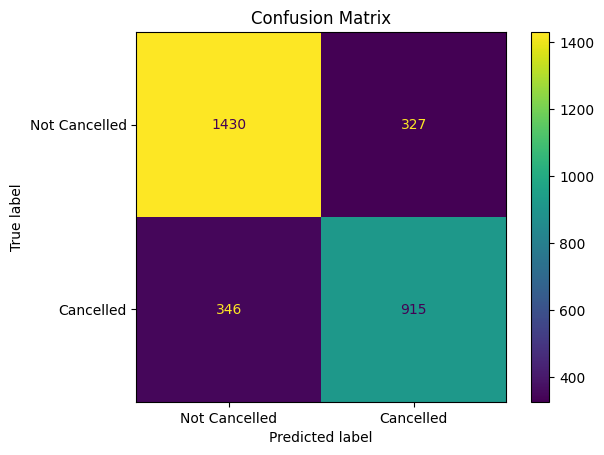

In [7]:
evaluate_model(default_tree, X_train, y_train, X_test, y_test)

### 1c. Tree size

In [8]:
print("Tree depth:", default_tree.get_depth())
print("Total nodes:", default_tree.tree_.node_count)
print("Number of leaves:", default_tree.get_n_leaves())

Tree depth: 36
Total nodes: 3991
Number of leaves: 1996


### 1d. First and second splits

In [9]:
feature_names = X.columns

tree = default_tree.tree_

root_feature = feature_names[tree.feature[0]]

left_child = tree.children_left[0]
right_child = tree.children_right[0]

left_feature = (feature_names[tree.feature[left_child]] if tree.feature[left_child] >= 0 else "Leaf")

right_feature = (feature_names[tree.feature[right_child]] if tree.feature[right_child] >= 0 else "Leaf")

print("First split:", root_feature)
print("Second split - left branch:", left_feature)
print("Second split - right branch:", right_feature)

First split: country_PRT
Second split - left branch: lead_time
Second split - right branch: lead_time


In [10]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": default_tree.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(5)

,Feature,Importance
0,lead_time,0.214544
123,country_PRT,0.146282
10,adr,0.138948
1,arrival_date_week_number,0.078134
2,arrival_date_day_of_month,0.076779


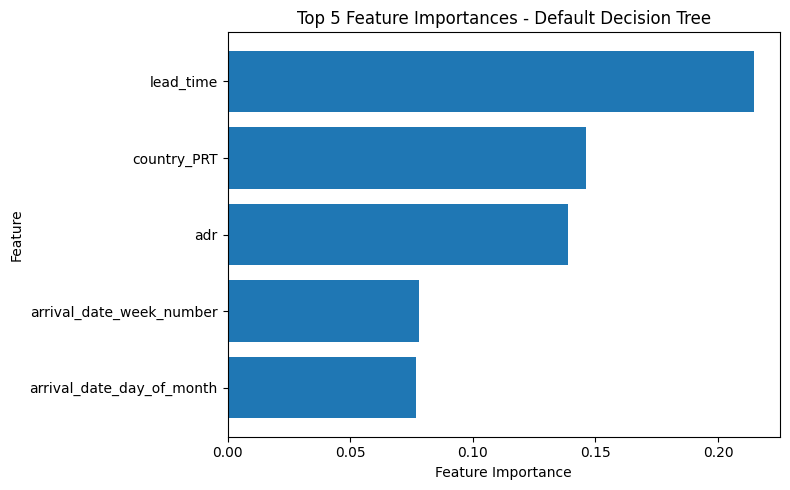

In [11]:
top5 = importance_df.head(5)

plt.figure(figsize=(8, 5))
plt.barh(top5["Feature"][::-1], top5["Importance"][::-1])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 5 Feature Importances - Default Decision Tree")

plt.tight_layout()
plt.show()

### 1f. Overfitting

The result shows the sign of overfitting with the result of training accuracy is alomst perfect whereas test accuracy is 77 percent. The model's accuracy drops significantly on unseen data. 

## Part 2 — Tuned Decision Tree

In [ ]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 8, 13, 14, 15],
    "min_samples_leaf": [5, 10, 20, 30, 40],
    "min_samples_split": [0.001, 0.005, 0.01, 0.05, 0.1],
    "max_leaf_nodes": [None, 3, 4, 5, 6],
    "splitter" : ["best", "random"],
}

In [ ]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=10,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV accuracy:")
print(grid_search.best_score_)

Training Accuracy: 0.8211799801126948
Test Accuracy: 0.7833001988071571
Precision: 0.7636837532580365
Recall: 0.697065820777161
Specificity: 0.8451906659077973
F1 Score: 0.7288557213930348
F2 Score: 0.7094430992736077
ROC-AUC: 0.8458160109082193


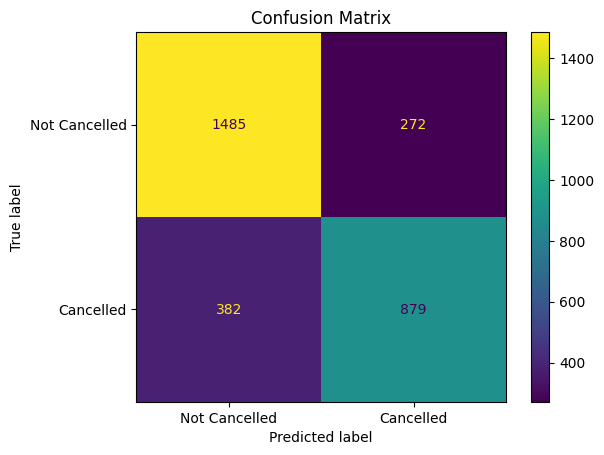

In [ ]:
evaluate_model(best_tree, X_train, y_train, X_test, y_test)